# Exploratory diagnostics — no_aerosols_zero_wind

Analyses that support but don't belong in `base_comparison.ipynb`:

1. Shell decomposition (Heus & Jonker 2008) — core / subsiding-shell mass flux
2. Convective velocity scale $w_*$
3. LWP integral time scale $T_\tau$
4. Lateral entrainment rate $\varepsilon(z)$


In [1]:
import sys
import warnings
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

_HERE = Path.cwd()
sys.path.insert(0, str(_HERE))
from cass_analysis import RT_LABEL, RT_STYLE, LST_OFFSET, rho, cp, Lv
from catalog import make_runset, CASS_ROOT

EXPT_KEY    = 'no_aerosols_zero_wind'
N_REPS      = 4
rs          = make_runset(EXPT_KEY, n_reps=N_REPS)
SAVE_PDF    = False
_SHELL_ROOT = CASS_ROOT / 'analysis' / 'shell' / EXPT_KEY

# Consumed by the w_* section below
CASES = [
    dict(key='1D', rt='2stream',   comp_expt=EXPT_KEY, comp_rt='2stream'),
    dict(key='3D', rt='raytracer', comp_expt=EXPT_KEY, comp_rt='raytracer'),
]


In [2]:
# ── Load per-rep shell caches ────────────────────────────────────────────
def _load_rt(rt):
    reps = []
    for i in range(1, N_REPS + 1):
        f = _SHELL_ROOT / rt / f'rep_{i:02d}' / 'shell.nc'
        if f.exists():
            reps.append(xr.open_dataset(f))
    return reps

D = {rt: _load_rt(rt) for rt in ('2stream', 'raytracer')}
for rt, reps in D.items():
    print(f'{rt}: {len(reps)} reps, snap dim = '
          f'{reps[0].sizes["snap"] if reps else "?"}, '
          f'z dim = {reps[0].sizes["z"] if reps else "?"}')


2stream: 4 reps, snap dim = 6, z dim = 256
raytracer: 4 reps, snap dim = 6, z dim = 256


In [3]:
# ── Ensemble mean ± SEM across reps, restricted to LST window ───────────
LST_LO, LST_HI = 14.0, 16.0

def _ens_mean(reps, varname, lst_lo=LST_LO, lst_hi=LST_HI):
    """Per-rep time-mean in LST window, then stack. Returns (n_reps, n_z)."""
    stack = []
    for ds in reps:
        lst = ds['lst'].values
        mask = (lst >= lst_lo) & (lst <= lst_hi)
        if not mask.any():
            continue
        # Time-mean over the selected snapshots for this rep
        stack.append(ds[varname].isel(snap=np.where(mask)[0]).mean('snap').values)
    return np.stack(stack) if stack else np.array([])

z = D['2stream'][0]['z'].values
regions = ['core', 'cloud_shell', 'subsiding_shell', 'env']

ens = {rt: {} for rt in ('2stream', 'raytracer')}
for rt in ('2stream', 'raytracer'):
    for r in regions:
        for f in ['area_frac', 'M', 'w', 'thl', 'qt', 'ql', 'b']:
            key = f'{r}_{f}'
            ens[rt][key] = _ens_mean(D[rt], key)
print('ensemble arrays built.')


ensemble arrays built.


## 1. Shell decomposition (Heus & Jonker 2008)

At each height, each grid cell is classified as:
- **core** — cloudy + rising (`ql > 1e-5` AND `w > 0`)
- **cloud shell** — cloudy + sinking (`ql > 1e-5` AND `w ≤ 0`)
- **subsiding shell** — clear, sinking, within 2 cells of cloud
- **env** — everything else

3D has stronger core updrafts *and* stronger compensating subsiding-shell
downdrafts at mid-cloud levels — the cumulus circulation amplifies under
3D RT. This is the dynamical counterpart to the extra cloud water and
higher cloud tops in the base figure.


/tmp/ipykernel_1397492/645380567.py:17: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


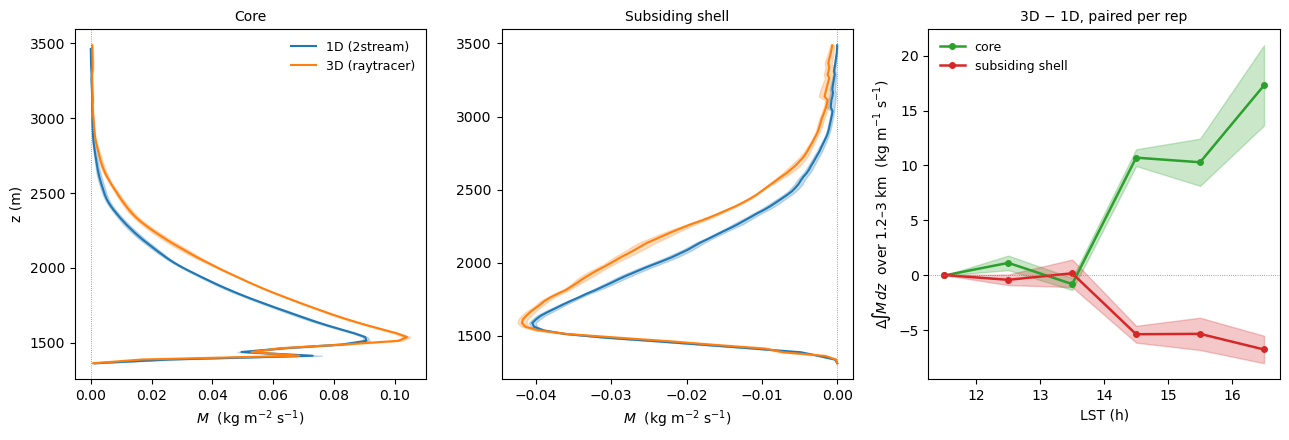

In [4]:
# ── Distilled shell figure: core M, subsiding-shell M, Δ(∫M dz) vs LST ─────
Z_MAX = 3500
zmsk  = z <= Z_MAX

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

# Panels 1 & 2: M profiles for core and subsiding shell
for ax, region, title in zip(
    axes[:2],
    ['core', 'subsiding_shell'],
    ['Core', 'Subsiding shell'],
):
    for rt in ('2stream', 'raytracer'):
        arr = ens[rt][f'{region}_M']
        if arr.size == 0:
            continue
        mean = np.nanmean(arr, axis=0)
        sem  = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])
        c = RT_STYLE[rt]['color']
        ax.plot(mean[zmsk], z[zmsk], color=c, lw=1.5, label=RT_LABEL[rt])
        ax.fill_betweenx(z[zmsk], (mean - sem)[zmsk], (mean + sem)[zmsk],
                         color=c, alpha=0.25)
    ax.axvline(0, color='0.5', lw=0.6, ls=':')
    ax.set_xlabel(r'$M$  (kg m$^{-2}$ s$^{-1}$)')
    ax.set_title(title, fontsize=10)
axes[0].set_ylabel('z (m)')
axes[0].legend(fontsize=9, frameon=False, loc='upper right')

# Panel 3: paired (3D − 1D) integrated M over 1.2–3 km vs LST
ax = axes[2]
z_r   = D['2stream'][0]['z'].values
sel_z = (z_r >= 1200) & (z_r <= 3000)
dz    = np.gradient(z_r)
region_colors = {'core': 'C2', 'subsiding_shell': 'C3'}
n_pair = min(len(D['2stream']), len(D['raytracer']))
for region, color in region_colors.items():
    per_rep_diff = []
    for r in range(n_pair):
        M_1d = D['2stream'][r][f'{region}_M'].values
        M_3d = D['raytracer'][r][f'{region}_M'].values
        n_snap = min(M_1d.shape[0], M_3d.shape[0])
        int_1d = np.nansum(M_1d[:n_snap, sel_z] * dz[sel_z], axis=1)
        int_3d = np.nansum(M_3d[:n_snap, sel_z] * dz[sel_z], axis=1)
        per_rep_diff.append(int_3d - int_1d)
    arr = np.stack(per_rep_diff)
    lst = D['2stream'][0]['lst'].values[:arr.shape[1]]
    mean = np.nanmean(arr, axis=0)
    sem  = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])
    ax.plot(lst, mean, color=color, lw=1.8, marker='o', markersize=4,
            label=region.replace('_', ' '))
    ax.fill_between(lst, mean - sem, mean + sem, color=color, alpha=0.25)
ax.axhline(0, color='0.5', lw=0.6, ls=':')
ax.set_xlabel('LST (h)')
ax.set_ylabel(r'$\Delta\!\int\!M\,dz$  over 1.2–3 km  (kg m$^{-1}$ s$^{-1}$)')
ax.set_title('3D − 1D, paired per rep', fontsize=10)
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.show()


## 2. Convective velocity scale $w_*$

Verzijlbergh et al. (2009) domain-integrated convective velocity scale:

$$w_* = \left( c_1 \frac{g}{\theta_0} \int_0^{L_z} \overline{w'\theta_v'}\, dz \right)^{1/3}$$

with $c_1 = 2.5$.  Computed from domain-mean `thv_flux` stats profiles, averaged over **13:00–14:00 LST**.

/tmp/ipykernel_1397492/2493926925.py:52: RuntimeWarning: Mean of empty slice
  mean=np.nanmean(stack, axis=0),
/tmp/ipykernel_1397492/2493926925.py:55: RuntimeWarning: Mean of empty slice
  f'peak w* = {np.nanmax(np.nanmean(stack, axis=0)):.2f} m/s')


1D: n_reps=4, nt=167, peak w* = 1.96 m/s
3D: n_reps=4, nt=167, peak w* = 2.01 m/s


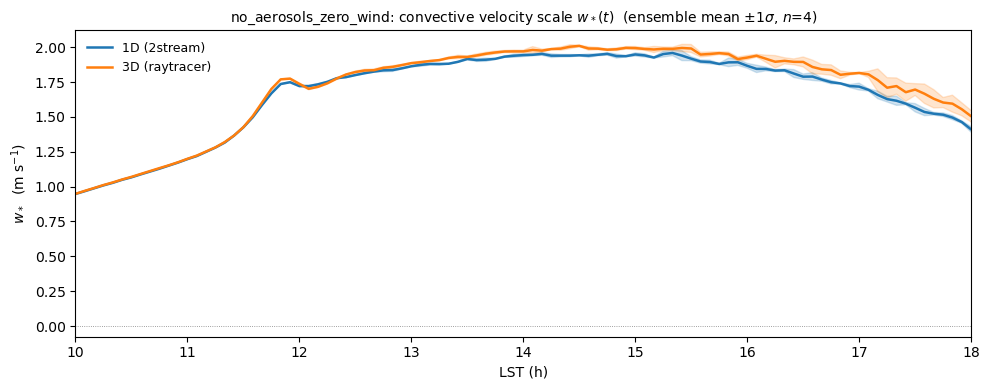


w_* averaged over LST windows (ensemble mean ± between-rep std):
window                  1D          3D         Δ
11–12 LST     1.463 ± 0.000   1.473 ± 0.001   +0.011
12–13 LST     1.793 ± 0.001   1.808 ± 0.001   +0.015
13–14 LST     1.902 ± 0.001   1.937 ± 0.001   +0.035
14–15 LST     1.942 ± 0.006   1.989 ± 0.004   +0.047
15–16 LST     1.915 ± 0.005   1.967 ± 0.007   +0.052
16–17 LST     1.786 ± 0.002   1.867 ± 0.013   +0.081


In [5]:
# ── w_* timeseries (Verzijlbergh et al. 2009) ───────────────────────────────
# w_*(t) = (c_1 * g / θ_0 * ∫ w'θ_v' dz)^(1/3)
# Computed at every stats timestep; ensemble mean ± between-rep std.
import netCDF4 as _nc4

C1 = 2.5
G  = 9.81

def compute_wstar_timeseries(run_dir):
    """Return (t_sec, w_star_series) for one rep.  NaN where integral ≤ 0."""
    stats_path = sorted(Path(run_dir).glob('cass.default.*.nc'))
    if not stats_path:
        return None, None
    ds = _nc4.Dataset(stats_path[0])
    t_sim  = np.asarray(ds.variables['time'][:])
    zh     = np.asarray(ds.variables['zh'][:])
    thvref = np.asarray(ds.groups['thermo'].variables['thvref'][:])
    flux   = np.asarray(ds.groups['thermo'].variables['thv_flux'][:])  # (time, zh)
    ds.close()

    integral = np.trapezoid(flux, zh, axis=1)    # K m²/s
    theta_0  = float(thvref.mean())
    wstar    = np.where(integral > 0,
                        (C1 * G / theta_0 * np.maximum(integral, 0.0))**(1./3.),
                        np.nan)
    return t_sim, wstar.astype(np.float32)


# ── compute for all reps × both RT; ensemble stack ──────────────────────────
wstar_ens = {}
for case in CASES:
    rt_key = case['key']
    run_root = Path(rs.root) / case['rt']
    t_ref, stack = None, []
    for i in range(1, N_REPS + 1):
        rep_dir = run_root / f'rep_{i:02d}'
        if not rep_dir.exists():
            continue
        t_sec, ws = compute_wstar_timeseries(rep_dir)
        if t_ref is None:
            t_ref = t_sec
        # Truncate all reps to shortest time axis
        n = min(len(t_ref), len(t_sec))
        if len(t_sec) < len(t_ref):
            t_ref = t_ref[:n]
        stack.append(ws[:n])
    # Align all stacked reps to n
    n_min = min(len(s) for s in stack)
    t_ref = t_ref[:n_min]
    stack = np.stack([s[:n_min] for s in stack], axis=0)
    wstar_ens[rt_key] = dict(t_sec=t_ref, stack=stack,
                             mean=np.nanmean(stack, axis=0),
                             std =np.nanstd(stack, axis=0, ddof=0))
    print(f'{rt_key}: n_reps={stack.shape[0]}, nt={stack.shape[1]}, '
          f'peak w* = {np.nanmax(np.nanmean(stack, axis=0)):.2f} m/s')

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for rt_key, case in zip(('1D', '3D'), CASES):
    e = wstar_ens[rt_key]
    lst = e['t_sec'] / 3600.0 + LST_OFFSET
    c   = RT_STYLE[case['rt']]['color']
    ax.plot(lst, e['mean'], color=c, lw=1.8, label=RT_LABEL[case['rt']])
    ax.fill_between(lst, e['mean'] - e['std'], e['mean'] + e['std'],
                    color=c, alpha=0.2)
ax.set_xlabel('LST (h)')
ax.set_ylabel(r'$w_*$  (m s$^{-1}$)')
ax.set_xlim(10, 18)
ax.set_xticks(np.arange(10, 18.1, 1))
ax.legend(fontsize=9, frameon=False)
ax.axhline(0, color='0.5', lw=0.6, ls=':')
ax.set_title(fr'{EXPT_KEY}: convective velocity scale $w_*(t)$  '
             fr'(ensemble mean $\pm 1\sigma$, $n$={N_REPS})', fontsize=10)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig(f'wstar_ts_{EXPT_KEY}.pdf', bbox_inches='tight')
plt.show()

# ── LST window summary (unchanged format, but over more windows) ────────────
print('\nw_* averaged over LST windows (ensemble mean ± between-rep std):')
print(f'{"window":<14}{"1D":>12}{"3D":>12}{"Δ":>10}')
for lo, hi in [(11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17)]:
    row = {}
    for rt_key, case in zip(('1D', '3D'), CASES):
        e = wstar_ens[rt_key]
        lst = e['t_sec'] / 3600.0 + LST_OFFSET
        m = (lst >= lo) & (lst < hi)
        per_rep = np.nanmean(e['stack'][:, m], axis=1)
        row[rt_key] = (np.nanmean(per_rep), np.nanstd(per_rep, ddof=0))
    d = row['3D'][0] - row['1D'][0]
    print(f'{lo:2d}–{hi:2d} LST    '
          f'{row["1D"][0]:6.3f} ± {row["1D"][1]:5.3f}  '
          f'{row["3D"][0]:6.3f} ± {row["3D"][1]:5.3f}  '
          f'{d:+7.3f}')


## 3. LWP integral time scale  $T_\tau$

Domain-mean sliding-window integral time scale of LWP (Taylor 1921, Stull 1988):

$$T_\tau(t) = \Delta t \sum_{\ell=0}^{\ell_0 - 1} \rho_\ell$$

where $\ell_0$ is the first lag where $\rho \leq 0$, estimated over a symmetric 2-hour window centred on $t$.

Cache built by `analysis/t_scale/compute_T_scale.py` (submit via `submit_T_scale.sh`).

2stream: 4 rep(s) loaded
raytracer: 4 rep(s) loaded


/tmp/ipykernel_1397492/964803901.py:37: RuntimeWarning: Mean of empty slice
  mu    = np.nanmean(stack, axis=0) / 60.0              # seconds → minutes
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


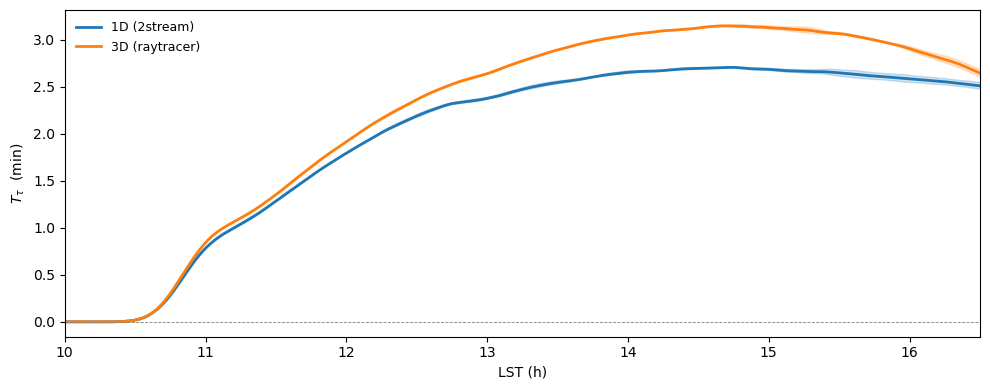

In [6]:
# ── Load T_scale cache ────────────────────────────────────────────────────────
_TS_ROOT = CASS_ROOT / 'analysis' / 'timescale' / EXPT_KEY

_RT_CFG = [
    ('2stream',   RT_STYLE['2stream']['color'], RT_LABEL['2stream']),
    ('raytracer', RT_STYLE['raytracer']['color'], RT_LABEL['raytracer']),
]

ts_data = {}
for rt, color, label in _RT_CFG:
    reps = []
    for i in range(1, N_REPS + 1):
        nc = _TS_ROOT / rt / f'rep_{i:02d}' / 'T_scale.nc'
        if not nc.exists():
            print(f'  MISSING: {nc}')
            continue
        ds_ts = xr.open_dataset(nc)
        reps.append({
            't_lst_h':      ds_ts.t_lst_h.values,
            'T_scale_mean': ds_ts.T_scale_mean.values,
        })
        ds_ts.close()
    ts_data[rt] = reps
    print(f'{rt}: {len(reps)} rep(s) loaded')

# ── Figure 7: domain-mean T_τ — 1D vs 3D ─────────────────────────────────────
LST_PLOT_MIN, LST_PLOT_MAX = 10.0, 16.5   # adjust as needed

fig, ax = plt.subplots(figsize=(10, 4))

for rt, color, label in _RT_CFG:
    reps = ts_data.get(rt, [])
    if not reps:
        continue
    t_h   = reps[0]['t_lst_h']
    stack = np.stack([r['T_scale_mean'] for r in reps])   # (n_reps, T)
    mu    = np.nanmean(stack, axis=0) / 60.0              # seconds → minutes
    sd    = np.nanstd(stack,  axis=0, ddof=0) / 60.0

    ax.plot(t_h, mu, color=color, lw=2.0, label=label)
    ax.fill_between(t_h, mu - sd, mu + sd, color=color, alpha=0.2)

ax.set_xlabel('LST (h)')
ax.set_ylabel(r'$T_\tau$  (min)')
ax.set_xlim(LST_PLOT_MIN, LST_PLOT_MAX)
ax.set_xticks(np.arange(LST_PLOT_MIN, LST_PLOT_MAX + 0.5, 1))
ax.axhline(0, color='gray', lw=0.6, ls='--')
ax.legend(fontsize=9, frameon=False)
# ax.set_title(
#     fr'{EXPT_KEY}: domain-mean LWP integral time scale'
#     r'  (window = 2 h,  nlags = 30 min,  ensemble mean $\pm1\sigma$)',
#     fontsize=10,
# )
plt.tight_layout()
if SAVE_PDF:
    plt.savefig(f'T_scale_{EXPT_KEY}.pdf', bbox_inches='tight')
    print(f'Saved T_scale_{EXPT_KEY}.pdf')
plt.show()

## 4. Lateral entrainment rate ε(z)

Per-updraft fractional entrainment rate from the quasi-steady plume equation
(Kuang & Bretherton 2006; Gentine et al. 2016):

$$\varepsilon(z) = -\frac{1}{h_u(z) - h_\mathrm{env}(z)}\,\frac{d h_u}{d z}$$

with frozen MSE $h = c_p\,\theta_l\,\Pi + g z + L_v q_t$ (warm-only, $q_i = 0$).
Updrafts: $q_l > 10^{-5}$ kg/kg AND $w > 1$ m/s, 3-D connected components, ≥8 cells,
≥3 vertical levels.  Environment: clear columns with a 2-cell subsiding shell excluded.

Cache built by `analysis/entrainment/compute_entrainment.py` (submit via
`submit_entrainment.sh`).  LST 11–17, hourly 3-D dumps, 4 reps × both RT.


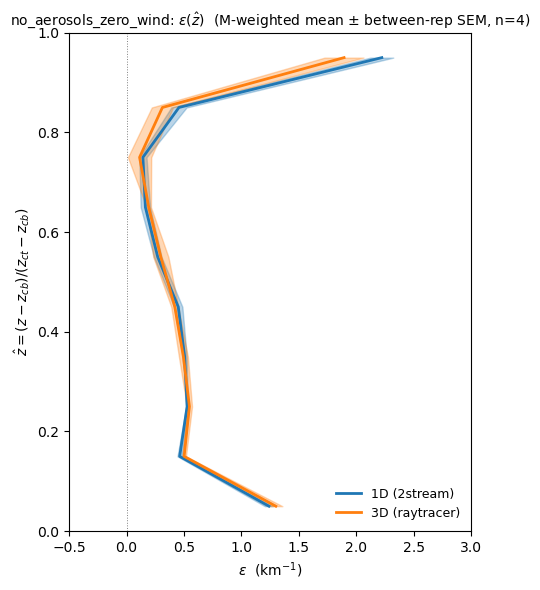

In [7]:
# ── Per-rep M-weighted mean in z_nd; show ensemble mean ± between-rep SEM ──
_ENTR_ROOT = CASS_ROOT / 'analysis' / 'entrainment' / EXPT_KEY
Z_ND_EDGES = np.linspace(0.0, 1.0, 11)
Z_ND_CENT  = 0.5 * (Z_ND_EDGES[:-1] + Z_ND_EDGES[1:])

def _per_rep_wmean_znd(rt, keys=('epsilon',)):
    """Return dict[key] → (n_reps, n_bins) M-weighted means in z_nd bins."""
    out = {k: [] for k in keys}
    for i in range(1, N_REPS + 1):
        f = _ENTR_ROOT / rt / f'rep_{i:02d}' / 'entrainment.nc'
        if not f.exists():
            continue
        with xr.open_dataset(f) as ds:
            pid = ds['plume_id'].values
            cb  = ds['plume_cb_z'].values[pid]
            ct  = ds['plume_ct_z'].values[pid]
            depth = np.where(ct - cb > 100.0, ct - cb, np.nan)
            z_nd = (ds['z'].values - cb) / depth
            M = ds['M'].values
            w = np.where(np.isfinite(M) & (M > 0), M, 0.0)
            for key in keys:
                y = ds[key].values
                means = np.full(len(Z_ND_CENT), np.nan)
                for j in range(len(Z_ND_CENT)):
                    sel = (z_nd >= Z_ND_EDGES[j]) & (z_nd < Z_ND_EDGES[j+1]) \
                          & np.isfinite(y) & (w > 0)
                    if sel.sum() < 20:
                        continue
                    means[j] = np.sum(w[sel] * y[sel]) / np.sum(w[sel])
                out[key].append(means)
    return {k: np.stack(v) for k, v in out.items()}

R_eps = {rt: _per_rep_wmean_znd(rt, keys=('epsilon',)) for rt in ('2stream', 'raytracer')}

# ── Figure: ε(ẑ) mean ± between-rep SEM ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 6))
for rt in ('2stream', 'raytracer'):
    arr = R_eps[rt]['epsilon'] * 1e3   # (n_reps, n_bins), /km
    mean = np.nanmean(arr, axis=0)
    sem  = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(arr), axis=0))
    ok = np.isfinite(mean)
    c = RT_STYLE[rt]['color']
    ax.plot(mean[ok], Z_ND_CENT[ok], color=c, lw=2.0, label=RT_LABEL[rt])
    ax.fill_betweenx(Z_ND_CENT[ok], (mean-sem)[ok], (mean+sem)[ok],
                     color=c, alpha=0.3)
ax.axvline(0, color='0.5', lw=0.7, ls=':')
ax.set_xlabel(r'$\varepsilon$  (km$^{-1}$)')
ax.set_ylabel(r'$\hat z = (z - z_{cb}) / (z_{ct} - z_{cb})$')
ax.set_xlim(-0.5, 3.0)
ax.set_ylim(0, 1)
ax.legend(fontsize=9, frameon=False, loc='lower right')
ax.set_title(fr'{EXPT_KEY}: $\varepsilon(\hat z)$  (M-weighted mean $\pm$ between-rep SEM, n={N_REPS})',
             fontsize=10)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig(f'entrainment_{EXPT_KEY}.pdf', bbox_inches='tight')
plt.show()


### ε and δ vs z  (dimensional, LST 14–16)


/tmp/ipykernel_1397492/3393897185.py:44: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/global/homes/m/mpowell/.conda/envs/xr_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


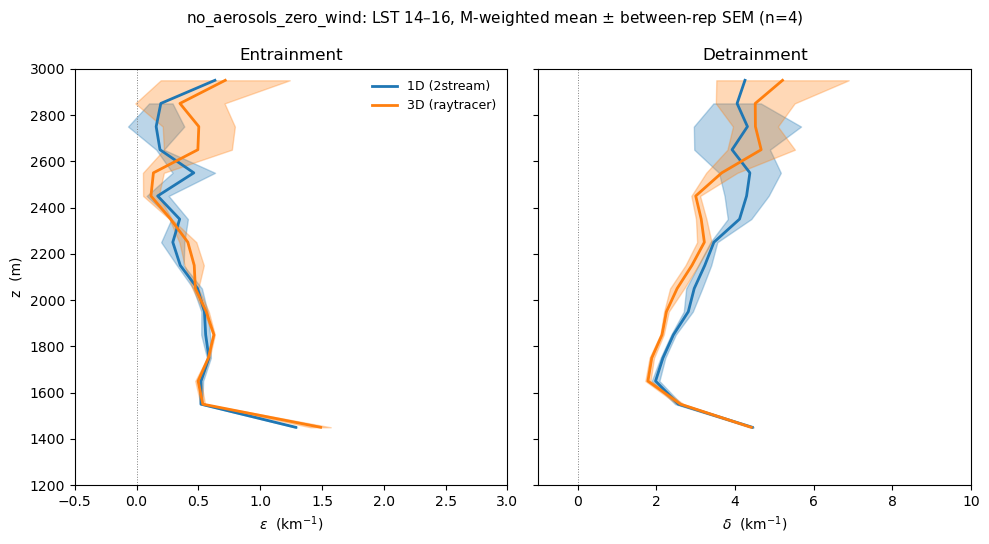

Paired per-rep differences (3D − 1D); |t|>3.18 ≈ p<0.05, df=3

  Entrainment:
   z (m)       1D       3D        Δ      t
    1450    1.287    1.489   +0.202  +2.56
    1550    0.521    0.536   +0.014  +0.60
    1650    0.521    0.498   -0.023  -0.62
    1750    0.585    0.581   -0.004  -0.19
    1850    0.559    0.625   +0.066  +1.94
    1950    0.549    0.563   +0.015  +0.43
    2050    0.493    0.475   -0.018  -0.78
    2150    0.353    0.466   +0.113  +1.38
    2250    0.293    0.414   +0.122  +1.41
    2350    0.348    0.275   -0.073  -1.04
    2450    0.170    0.116   -0.054  -0.36
    2550    0.463    0.136   -0.327  -1.27
    2650    0.189    0.496   +0.306  +1.22
    2750    0.158    0.503   +0.345  +0.88
    2850    0.196    0.351   -0.198  -4.90

  Detrainment:
   z (m)       1D       3D        Δ      t
    1450    4.437    4.411   -0.026  -0.41
    1550    2.556    2.610   +0.054  +0.34
    1650    1.978    1.784   -0.194  -1.39
    1750    2.166    1.882   -0.284  -5.65
   

In [8]:
# ── ε and δ vs z  (dimensional, LST 14–16) ──────────────────────────────────
# M-weighted mean ± between-rep SEM, K&B 2006 / Gentine 2016 methodology.
LST_LO_22, LST_HI_22 = 14.0, 16.0
Z_EDGES_22 = np.arange(1200.0, 3001.0, 100.0)
Z_CENT_22  = 0.5 * (Z_EDGES_22[:-1] + Z_EDGES_22[1:])

def _per_rep_wmean_z(rt, keys):
    out = {k: [] for k in keys}
    for i in range(1, N_REPS + 1):
        f = _ENTR_ROOT / rt / f'rep_{i:02d}' / 'entrainment.nc'
        if not f.exists():
            continue
        with xr.open_dataset(f) as ds:
            pid   = ds['plume_id'].values
            lst_s = ds['plume_lst'].values[pid]
            z     = ds['z'].values
            M     = ds['M'].values
            keep = ((lst_s >= LST_LO_22) & (lst_s <= LST_HI_22)
                    & np.isfinite(z) & np.isfinite(M) & (M > 0))
            for key in keys:
                y = ds[key].values
                w = np.where(keep & np.isfinite(y), M, 0.0)
                means = np.full(len(Z_CENT_22), np.nan)
                for j in range(len(Z_CENT_22)):
                    sel = (z >= Z_EDGES_22[j]) & (z < Z_EDGES_22[j+1]) & (w > 0)
                    if sel.sum() < 20:
                        continue
                    means[j] = np.sum(w[sel] * y[sel]) / np.sum(w[sel])
                out[key].append(means)
    return {k: np.stack(v) if v else np.array([]) for k, v in out.items()}

R_ed = {rt: _per_rep_wmean_z(rt, ('epsilon', 'delta')) for rt in ('2stream', 'raytracer')}

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), sharey=True)
panels = [
    ('epsilon', r'$\varepsilon$  (km$^{-1}$)', 1e3, (-0.5, 3.0), 'Entrainment'),
    ('delta',   r'$\delta$  (km$^{-1}$)',      1e3, (-1, 10),    'Detrainment'),
]
for ax, (key, xlbl, scale, xlim, title) in zip(axes, panels):
    for rt in ('2stream', 'raytracer'):
        arr = R_ed[rt][key] * scale
        if arr.size == 0:
            continue
        mean = np.nanmean(arr, axis=0)
        sem  = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(arr), axis=0))
        ok = np.isfinite(mean)
        c = RT_STYLE[rt]['color']
        ax.plot(mean[ok], Z_CENT_22[ok], color=c, lw=2.0, label=RT_LABEL[rt])
        ax.fill_betweenx(Z_CENT_22[ok], (mean-sem)[ok], (mean+sem)[ok], color=c, alpha=0.3)
    ax.axvline(0, color='0.5', lw=0.7, ls=':')
    ax.set_xlabel(xlbl)
    ax.set_xlim(*xlim)
    ax.set_title(title)
axes[0].set_ylabel('z  (m)')
axes[0].set_ylim(Z_EDGES_22[0], Z_EDGES_22[-1])
axes[0].legend(fontsize=9, frameon=False, loc='upper right')
fig.suptitle(fr'{EXPT_KEY}: LST {LST_LO_22:.0f}–{LST_HI_22:.0f}, M-weighted mean $\pm$ between-rep SEM (n={N_REPS})',
             fontsize=11)
plt.tight_layout()
if SAVE_PDF:
    plt.savefig(f'eps_delta_z_{EXPT_KEY}.pdf', bbox_inches='tight')
plt.show()

print('Paired per-rep differences (3D − 1D); |t|>3.18 ≈ p<0.05, df=3')
for key, xlbl, scale, _, title in panels:
    a1 = R_ed['2stream'][key]   * scale
    a3 = R_ed['raytracer'][key] * scale
    if a1.size == 0 or a3.size == 0:
        continue
    print(f'\n  {title}:')
    print(f'  {"z (m)":>6} {"1D":>8} {"3D":>8} {"Δ":>8} {"t":>6}')
    for j in range(len(Z_CENT_22)):
        d = a3[:, j] - a1[:, j]
        d = d[np.isfinite(d)]
        if len(d) < 2:
            continue
        m = d.mean(); s = d.std(ddof=1) / np.sqrt(len(d))
        t = m / s if s > 0 else np.nan
        print(f'  {Z_CENT_22[j]:>6.0f} {np.nanmean(a1[:,j]):>8.3f} '
              f'{np.nanmean(a3[:,j]):>8.3f} {m:>+8.3f} {t:>+6.2f}')


## 5. Composite shadow — exploratory archive

This section parks the full composite-shadow exploration code. All the
function definitions and loaders remain runnable; the *invocation* cells
are marked `# DISABLED` because:

- **xz/yz shadow figures** (3 × 2 = 6 figures): superseded by the
  azimuth-rotated version (moved to `base_comparison.ipynb §3` with the 1D
  row removed for density).
- **Resolved turbulent-flux azimuth composites** (`w'θ'_l`, `w'q_v'`): not
  used in the committee report — the flux signal is carried by the SEB
  conditioned panels in base §2.
- **Full azimuth-with-1D-row figures**: 1D composites are azimuthally
  isotropic by construction, so that row doubles up information that's
  already in the diff. Pruned from the report version in base §3.

**Surface-field distributions** (near-surface θ_l', q_t', b', SW↓, fluxes;
cloud-base / subcloud perturbations) are kept *active* below — they're
exploratory, not in the report, but still useful for diagnosing the
subcloud structure story.


In [ ]:
# ── §5 shared setup: imports + CASES with run_root for xy-field loaders ────
sys.path.insert(0, str(Path.cwd() / 'cloud_roots'))

from cass_analysis import (
    plot_cloud_root_composite, plot_circulation_composite,
    load_sfc_sw_dn, XL_GRID,
)
from cloud_root_composite_average import (
    average_reps, average_reps_windowed, average_reps_azimuth,
)
from sw_surface_composite import WINDOWS as SZA_WINDOWS, WINDOW_LABELS as SZA_LABELS

COMPOSITE_ROOT = str(CASS_ROOT / 'analysis' / 'cloud_root_composite')

# CASES extended with run_root for surface-distribution loader
CASES_X = [dict(**c, run_root=str(rs.root / c['rt'])) for c in CASES]


In [ ]:
# ── §5 load composite + sw data (needed by all archived call cells) ───────
comp_windowed = {}
for case in CASES:
    comp_windowed[case['key']] = average_reps_windowed(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        windows=SZA_WINDOWS, window_labels=SZA_LABELS,
        n_reps=N_REPS, verbose=False,
    )

comp_az_data = {}
for case in CASES:
    comp_az_data[case['key']] = average_reps_azimuth(
        Path(COMPOSITE_ROOT), case['comp_expt'], case['comp_rt'],
        windows=SZA_WINDOWS, window_labels=SZA_LABELS,
        n_reps=N_REPS, verbose=False,
    )

sw_data = {}
for case in CASES:
    rt, key = case['comp_rt'], case['key']
    reps_xz, reps_yz, reps_dm = [], [], []
    for i in range(1, N_REPS + 1):
        nc = Path(COMPOSITE_ROOT) / EXPT_KEY / rt / f'rep_{i:02d}' / 'sw_composite.nc'
        if not nc.exists():
            continue
        with xr.open_dataset(nc) as ds_sw:
            if 'Q_mean_xz' in ds_sw:     reps_xz.append(ds_sw['Q_mean_xz'].values)
            if 'Q_mean_yz' in ds_sw:     reps_yz.append(ds_sw['Q_mean_yz'].values)
            if 'Q_domain_mean' in ds_sw: reps_dm.append(ds_sw['Q_domain_mean'].values)
    _ens = lambda reps: None if not reps else np.nanmean(np.stack(reps), axis=0)
    sw_data[key] = dict(Q_xz=_ens(reps_xz), Q_yz=_ens(reps_yz),
                        Q_domain_mean=_ens(reps_dm))
print('tmp §5 composites + sw_data loaded.')


In [ ]:
# ── §5 archived plotting functions (xz/yz, full azimuth, flux composites) ──
def _plot_composite_figure(avail_orient, orient):
    """Draw composite figure for one orientation (xz or yz).

    Rows: 1D, 3D, then 3D−1D diff (if both available).
    Only the bottom row gets an x/L or y/L label.
    """
    if not avail_orient:
        print(f'No {orient} composite data — skipping.')
        return

    def _collect(vn):
        return np.concatenate([ds[vn].values.ravel() for ds in avail_orient.values()])

    vmax_thl = float(np.nanpercentile(np.abs(_collect('w_thl_mean')), 98))
    vmax_qv  = float(np.nanpercentile(np.abs(_collect('w_qv_mean')),  98))
    vlim_thl = (-vmax_thl, vmax_thl)
    vlim_qv  = (-vmax_qv,  vmax_qv)

    _plot_rows = [c for c in CASES if c['key'] in avail_orient]
    _has_diff  = '1D' in avail_orient and '3D' in avail_orient
    n_rows     = len(_plot_rows) + (1 if _has_diff else 0)

    fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, case in enumerate(_plot_rows):
        is_bottom = (row == n_rows - 1)
        plot_cloud_root_composite(
            axes[row, 0], axes[row, 1],
            avail_orient[case['key']],
            vlim_thl=vlim_thl, vlim_qv=vlim_qv,
            label=RT_LABEL[case['rt']],
            show_xlabel=is_bottom,
            orient=orient,
        )

    if _has_diff:
        row   = len(_plot_rows)   # always the bottom row
        ds_3d = avail_orient['3D']
        ds_1d = avail_orient['1D']
        xL    = ds_3d.xL.values
        z_nd  = ds_3d.z_nd.values
        hl    = 'x/L' if orient == 'xz' else 'y/L'

        for col, (var, cmap, clabel) in enumerate([
            ('w_thl_mean', 'RdBu_r', "Δw'θ_l'  (K m s⁻¹)"),
            ('w_qv_mean',  'BrBG',   "Δw'q_v'  (g kg⁻¹ m s⁻¹)"),
        ]):
            ax   = axes[row, col]
            diff = ds_3d[var].values - ds_1d[var].values
            vmax = float(np.nanpercentile(np.abs(diff), 98))
            pcm  = ax.pcolormesh(xL, z_nd, diff, cmap=cmap, shading='auto',
                                  vmin=-vmax, vmax=vmax)
            plt.colorbar(pcm, ax=ax, label=clabel)
            ax.axvline(-0.5, color='0.4', lw=0.8, ls='--')
            ax.axvline( 0.5, color='0.4', lw=0.8, ls='--')
            ax.axhline( 1.0, color='0.4', lw=0.8, ls=':')
            ax.set_xlabel(hl)          # always shown — this IS the bottom row
            ax.set_ylabel('z / z_sl')
            ax.set_xlim(-1, 1)
            ax.set_ylim(0, 1.0)
            ax.set_title(f"3D − 1D  —  {clabel.split('(')[0].strip()}")

    plt.suptitle(
        f'{EXPT_KEY}: cloud-root composites + 3D − 1D  ({orient})  '
        '[11:30–17:00 LST,  chord ≥ 1 km]',
        y=1.01,
    )
    plt.tight_layout()
    if SAVE_PDF:
        fname = f'composites_baseline_{orient}.pdf'
        plt.savefig(fname, bbox_inches='tight')
        print(f'Saved {fname}')
    plt.show()


_plot_composite_figure(_avail['xz'], 'xz')
_plot_composite_figure(_avail['yz'], 'yz')

def _plot_diff_circulation(ax, ds_3d, ds_1d, vlim_b, orient='xz',
                           show_xlabel=True, quiver_stride=(10, 5),
                           quiver_scale=None):
    """Plot 3D − 1D difference for b', horiz_wind', w'.  Returns pcm."""
    xL   = ds_3d.xL.values
    z_nd = ds_3d.z_nd.values

    b_diff = ds_3d['b_prime_mean'].values - ds_1d['b_prime_mean'].values
    u_diff = (ds_3d['horiz_wind_prime_mean'].values
              - ds_1d['horiz_wind_prime_mean'].values)
    w_diff = ds_3d['w_prime_mean'].values - ds_1d['w_prime_mean'].values

    pcm = ax.pcolormesh(xL, z_nd, b_diff, cmap='RdBu_r', shading='auto',
                        vmin=vlim_b[0], vmax=vlim_b[1])

    sx, sz = quiver_stride
    xi = np.arange(0, len(xL), sx)
    zi = np.arange(0, len(z_nd), sz)
    Xq, Zq = np.meshgrid(xL[xi], z_nd[zi])
    Uq = u_diff[np.ix_(zi, xi)]
    Wq = w_diff[np.ix_(zi, xi)]

    qkw = dict(pivot='mid', color='k', linewidth=0.4, alpha=0.75)
    if quiver_scale is not None:
        qkw['scale'] = quiver_scale
    ax.quiver(Xq, Zq, Uq, Wq, **qkw)

    xlabel = 'x/L' if orient == 'xz' else 'y/L'
    wind_label = "u'" if orient == 'xz' else "v'"
    ax.axvline(-0.5, color='0.4', lw=0.8, ls='--')
    ax.axvline( 0.5, color='0.4', lw=0.8, ls='--')
    ax.axhline( 1.0, color='0.4', lw=0.8, ls=':')
    if show_xlabel:
        ax.set_xlabel(xlabel)
    ax.set_ylabel('z / z_sl')
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1.0)

    # Event counts
    def _nev(ds):
        if 'n_events_per_rep' in ds:
            return int(ds['n_events_per_rep'].values.sum())
        return '?'
    n1, n3 = _nev(ds_1d), _nev(ds_3d)
    ax.set_title(f"3D − 1D  Δb' + (Δ{wind_label}, Δw')  ({n3}−{n1} events)")
    return pcm


def _compute_global_limits(comp_windowed, orientations=('xz', 'yz')):
    """Precompute shared vlim_b and quiver_scale across ALL windows and orientations."""
    n_win = len(SZA_WINDOWS)
    all_b   = []
    all_mag = []
    for orient in orientations:
        for wi in range(n_win):
            for case_key in ('1D', '3D'):
                ds = comp_windowed.get(case_key, {}).get(wi, {}).get(orient)
                if ds is None or 'b_prime_mean' not in ds:
                    continue
                all_b.append(ds['b_prime_mean'].values.ravel())
                u = ds['horiz_wind_prime_mean'].values
                w = ds['w_prime_mean'].values
                all_mag.append(np.sqrt(u**2 + w**2).ravel())

            # Also include diff fields
            ds_1d = comp_windowed.get('1D', {}).get(wi, {}).get(orient)
            ds_3d = comp_windowed.get('3D', {}).get(wi, {}).get(orient)
            if (ds_1d is not None and ds_3d is not None
                    and 'b_prime_mean' in ds_1d and 'b_prime_mean' in ds_3d):
                b_diff = ds_3d['b_prime_mean'].values - ds_1d['b_prime_mean'].values
                all_b.append(b_diff.ravel())
                u_d = ds_3d['horiz_wind_prime_mean'].values - ds_1d['horiz_wind_prime_mean'].values
                w_d = ds_3d['w_prime_mean'].values - ds_1d['w_prime_mean'].values
                all_mag.append(np.sqrt(u_d**2 + w_d**2).ravel())

    all_b   = np.concatenate(all_b)
    all_mag = np.concatenate(all_mag)
    vmax_b  = float(np.nanpercentile(np.abs(all_b[np.isfinite(all_b)]), 98))
    mag98   = float(np.nanpercentile(all_mag[np.isfinite(all_mag)], 98))
    return (-vmax_b, vmax_b), mag98 * 10


def _plot_shadow_figure_windowed(orient, vlim_b=None, shared_qscale=None):
    """One figure per zenith-angle window: 1D, 3D, diff, SW% anomaly.

    Uses comp_windowed (per-window composites) and sw_data.
    All panels share a single colorbar and vector scale.
    The SW panel shows percent deviation from domain-mean SW↓.
    """
    n_win = len(SZA_WINDOWS)
    has_both = '1D' in comp_windowed and '3D' in comp_windowed
    Q_key   = f'Q_{orient}'
    hl      = 'x/L' if orient == 'xz' else 'y/L'

    for wi in range(n_win):
        win_label = SZA_LABELS[wi]

        # Gather per-window datasets for this orientation
        ds_1d = comp_windowed.get('1D', {}).get(wi, {}).get(orient)
        ds_3d = comp_windowed.get('3D', {}).get(wi, {}).get(orient)

        avail_panels = []
        if ds_1d is not None and 'b_prime_mean' in ds_1d:
            avail_panels.append(('1D', ds_1d))
        if ds_3d is not None and 'b_prime_mean' in ds_3d:
            avail_panels.append(('3D', ds_3d))

        if not avail_panels:
            print(f'Window {wi} ({win_label}): no {orient} data — skipping.')
            continue

        has_diff = has_both and ds_1d is not None and ds_3d is not None \
                   and 'b_prime_mean' in ds_1d and 'b_prime_mean' in ds_3d

        # ── Figure layout ────────────────────────────────────────────────
        n_circ = len(avail_panels) + (1 if has_diff else 0)  # 1D, 3D, diff
        n_rows = n_circ + 1   # + SW% panel
        h_ratios = [4] * n_circ + [1]
        fig = plt.figure(figsize=(8, 4.5 * n_circ + 2))

        # Use GridSpec with a thin column for shared colorbar
        gs = fig.add_gridspec(n_rows, 2, width_ratios=[1, 0.03],
                              height_ratios=h_ratios, hspace=0.12, wspace=0.04)

        ax_circ = []
        for r in range(n_circ):
            ax = fig.add_subplot(gs[r, 0])
            ax_circ.append(ax)
            ax.tick_params(labelbottom=False)

        ax_sw = fig.add_subplot(gs[n_circ, 0], sharex=ax_circ[0])

        # ── Circulation panels (1D, 3D) ─────────────────────────────────
        case_labels = {'1D': '1D', '3D': '3D'}
        pcm = None
        for row, (key, ds) in enumerate(avail_panels):
            pcm = plot_circulation_composite(
                ax_circ[row], ds,
                vlim_b=vlim_b,
                label=case_labels.get(key, key),
                show_xlabel=False,
                orient=orient,
                show_colorbar=False,
                quiver_scale=shared_qscale,
            )

        # ── Difference panel ─────────────────────────────────────────────
        if has_diff:
            diff_row = len(avail_panels)
            pcm_diff = _plot_diff_circulation(
                ax_circ[diff_row], ds_3d, ds_1d,
                vlim_b=vlim_b, orient=orient,
                show_xlabel=False,
                quiver_scale=shared_qscale,
            )



        # ── SW % anomaly panel ───────────────────────────────────────────
        ax_sw.axhline(0, color='0.6', lw=0.5, ls='--')
        ax_sw.axvline(-0.5, color='0.4', lw=0.8, ls='--')
        ax_sw.axvline( 0.5, color='0.4', lw=0.8, ls='--')

        sw_plotted = False
        for key, ds in avail_panels:
            sd    = sw_data.get(key, {})
            Q_arr = sd.get(Q_key)      # (n_win, 200) or None
            if Q_arr is not None and wi < Q_arr.shape[0]:
                Q_win = Q_arr[wi]
                Q_dm  = sd.get('Q_domain_mean')
                if not np.all(np.isnan(Q_win)):
                    # Use true domain-mean SW↓ as reference (not profile mean)
                    if Q_dm is not None and wi < len(Q_dm) and Q_dm[wi] > 0:
                        Q_ref = Q_dm[wi]
                    else:
                        Q_ref = np.nanmean(Q_win)  # fallback
                    Q_pct = 100.0 * (Q_win - Q_ref) / Q_ref
                    color = RT_STYLE['2stream']['color'] if key == '1D' else RT_STYLE['raytracer']['color']

                    ax_sw.plot(XL_GRID, Q_pct, color=color, lw=1.8,
                              label=f'{case_labels.get(key, key)}')
                    sw_plotted = True

        cbar_ax = fig.add_subplot(gs[:n_circ, 1])
        fig.colorbar(pcm, cax=cbar_ax, label="b'  (m s⁻²)")

        if not sw_plotted:
            ax_sw.text(0.5, 0.5, 'no sw_composite data',
                       transform=ax_sw.transAxes, ha='center', va='center',
                       fontsize=8, color='gray')

        ax_sw.set_ylabel('ΔSW↓ (%)', fontsize=8)
        ax_sw.set_xlim(-1, 1)
        ax_sw.set_xlabel(hl)
        ax_sw.legend(fontsize=7, frameon=False, loc='lower right')

        plt.suptitle(
f'{EXPT_KEY}: b\' + circulation + SW% anomaly ({orient})\n'
            f'Window {win_label}',
            y=0.925,
        )
        plt.tight_layout()
        if SAVE_PDF:
            fname = f'shadow_{orient}_win{wi}.pdf'
            plt.savefig(fname, bbox_inches='tight')
            print(f'Saved {fname}')
        plt.show()


def _blend_sw(sd, sp, cp, direction):
    """Blend xz/yz SW profiles using azimuth weights."""
    Qx, Qy = sd.get('Q_xz'), sd.get('Q_yz')
    if Qx is None or Qy is None:
        return None
    if direction == 'parallel':
        return sp**2 * Qx + cp**2 * Qy
    else:
        return cp**2 * Qx + sp**2 * Qy


def _plot_shadow_figure_azimuth(comp_az_data, vlim_b=None, shared_qscale=None):
    """Azimuth-rotated version of _plot_shadow_figure_windowed.

    Parameters
    ----------
    comp_az_data : dict  {case_key: {wi: {'parallel': ds, 'perpendicular': ds, ...}}}
    """
    n_win = len(SZA_WINDOWS)

    for wi in range(n_win):
        win_label = SZA_LABELS[wi]

        # Gather available panels
        avail_panels = []
        az_stats = None
        for case_key, case_label in [('1D', '1D'), ('3D', '3D')]:
            wi_data = comp_az_data.get(case_key, {}).get(wi, {})
            ds_par  = wi_data.get('parallel')
            ds_perp = wi_data.get('perpendicular')
            if ds_par is not None and ds_perp is not None:
                avail_panels.append((case_key, case_label, ds_par, ds_perp))
                if az_stats is None:
                    az_stats = wi_data.get('azimuth_stats')

        if not avail_panels:
            print(f'Window {wi} ({win_label}): no azimuth-rotated data — skipping.')
            continue

        has_diff = len(avail_panels) == 2

        # ── Figure layout: 2 columns (par, perp) + 1 thin cbar column ───
        n_circ = len(avail_panels) + (1 if has_diff else 0)
        n_rows = n_circ + 1   # + SW% panel
        h_ratios = [4] * n_circ + [1]

        fig = plt.figure(figsize=(15, 4.5 * n_circ + 2))
        gs = fig.add_gridspec(n_rows, 3,
                              width_ratios=[1, 1, 0.03],
                              height_ratios=h_ratios,
                              hspace=0.12, wspace=0.08)

        pcm_last = None  # save for shared colorbar

        for col_idx, direction in enumerate(['parallel', 'perpendicular']):
            c0 = col_idx  # 0 for parallel, 1 for perpendicular

            ax_circ = []
            for r in range(n_circ):
                ax = fig.add_subplot(gs[r, c0])
                ax_circ.append(ax)
                ax.tick_params(labelbottom=False)

            ax_sw = fig.add_subplot(gs[n_circ, c0], sharex=ax_circ[0])

            # ── Circulation panels ───────────────────────────────────────
            pcm = None
            for row, (key, label, ds_par, ds_perp) in enumerate(avail_panels):
                ds = ds_par if direction == 'parallel' else ds_perp
                pcm = plot_circulation_composite(
                    ax_circ[row], ds,
                    vlim_b=vlim_b,
                    label=label,
                    show_xlabel=False,
                    orient='xz',
                    show_colorbar=False,
                    quiver_scale=shared_qscale,
                )
                dir_sym = 'u_\u2225' if direction == 'parallel' else 'u_\u22a5'
                n_ev = '?'
                if 'n_events_per_rep' in ds:
                    n_ev = int(ds['n_events_per_rep'].values.sum())
                ax_circ[row].set_title(
                    f"{label}  b' + ({dir_sym}, w')  ({n_ev} events)")

            if pcm is not None:
                pcm_last = pcm

            # ── Difference panel ─────────────────────────────────────────
            if has_diff:
                ds_3d = avail_panels[1][2] if direction == 'parallel' else avail_panels[1][3]
                ds_1d = avail_panels[0][2] if direction == 'parallel' else avail_panels[0][3]
                diff_row = len(avail_panels)
                _plot_diff_circulation(
                    ax_circ[diff_row], ds_3d, ds_1d,
                    vlim_b=vlim_b, orient='xz',
                    show_xlabel=False,
                    quiver_scale=shared_qscale,
                )
                dir_sym = 'u_\u2225' if direction == 'parallel' else 'u_\u22a5'
                ax_circ[diff_row].set_title(
                    f"3D \u2212 1D  \u0394b' + (\u0394{dir_sym}, \u0394w')")

            # ── Axis labels ──────────────────────────────────────────────
            hl = 'r_\u2225 / L' if direction == 'parallel' else 'r_\u22a5 / L'
            for ax in ax_circ:
                ax.set_ylabel('z / z_sl' if col_idx == 0 else '')
                ax.set_xlim(-1, 1)
                ax.set_ylim(0, 1.0)
                if col_idx == 1:
                    ax.tick_params(labelleft=False)

            # ── SW % anomaly panel ───────────────────────────────────────
            ax_sw.axhline(0, color='0.6', lw=0.5, ls='--')
            ax_sw.axvline(-0.5, color='0.4', lw=0.8, ls='--')
            ax_sw.axvline( 0.5, color='0.4', lw=0.8, ls='--')

            # SW blending uses mean azimuth for this window (already averaged)
            sw_plotted = False
            if az_stats is not None:
                az_mean = az_stats['mean']
                sp_mean = np.sin(np.radians(az_mean))
                cp_mean = np.cos(np.radians(az_mean))
                for key, label, _, _ in avail_panels:
                    sd = sw_data.get(key, {})
                    Q_blend = _blend_sw(sd, sp_mean, cp_mean, direction)
                    if Q_blend is not None and wi < Q_blend.shape[0]:
                        Q_win = Q_blend[wi]
                        Q_dm  = sd.get('Q_domain_mean')
                        if not np.all(np.isnan(Q_win)):
                            Q_ref = Q_dm[wi] if (Q_dm is not None and wi < len(Q_dm) and Q_dm[wi] > 0) else np.nanmean(Q_win)
                            Q_pct = 100.0 * (Q_win - Q_ref) / Q_ref
                            color = RT_STYLE['2stream']['color'] if key == '1D' else RT_STYLE['raytracer']['color']
                            ax_sw.plot(XL_GRID, Q_pct, color=color, lw=1.8, label=label)
                            sw_plotted = True

            if not sw_plotted:
                ax_sw.text(0.5, 0.5, 'no sw_composite data',
                           transform=ax_sw.transAxes, ha='center', va='center',
                           fontsize=8, color='gray')

            ax_sw.set_ylabel('\u0394SW\u2193 (%)' if col_idx == 0 else '', fontsize=8)
            ax_sw.set_xlim(-1, 1)
            ax_sw.set_xlabel(hl)
            ax_sw.legend(fontsize=7, frameon=False, loc='lower right')
            if col_idx == 1:
                ax_sw.tick_params(labelleft=False)

            # Column title
            ax_circ[0].text(0.5, 1.15, direction.capitalize(),
                            transform=ax_circ[0].transAxes,
                            ha='center', va='bottom', fontsize=12, fontweight='bold')

        # ── Shared colorbar on the far right ─────────────────────────────
        if pcm_last is not None:
            cbar_ax = fig.add_subplot(gs[:n_circ, 2])
            fig.colorbar(pcm_last, cax=cbar_ax, label="b'  (m s\u207b\u00b2)")

        # Suptitle with azimuth stats
        az_str = ''
        if az_stats is not None:
            az_str = (f'\n\u03c6_az = {az_stats["mean"]:.0f}\u00b0 \u00b1 {az_stats["std"]:.0f}\u00b0  '
                      f'(range {az_stats["min"]:.0f}\u2013{az_stats["max"]:.0f}\u00b0, '
                      f'n={az_stats["n"]} matched events)')

        plt.suptitle(
            f'Window {win_label}{az_str}',
            y=0.98, fontsize=11,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        if SAVE_PDF:
            fname = f'shadow_azimuth_win{wi}.pdf'
            plt.savefig(fname, bbox_inches='tight')
            print(f'Saved {fname}')
        plt.show()

def _plot_flux_composites_azimuth(comp_az_data, title_prefix=""):
    """Plot w'theta' and w'q' composites in azimuth-parallel/perpendicular layout.

    Rows: 1D, 3D, 3D-1D diff.  Columns: parallel, perpendicular.
    Two separate figures: one for w'theta', one for w'q'.
    """
    n_win = len(SZA_WINDOWS)

    for vn, cmap, clabel, scale in [
        ("w_thl_mean", "RdBu_r", "w'\u03b8_l'  (K m s\u207b\u00b9)", 1.0),
        ("w_qv_mean",  "BrBG",   "w'q_v'  (g kg\u207b\u00b9 m s\u207b\u00b9)", 1e3),
    ]:
        for wi in range(n_win):
            win_label = SZA_LABELS[wi]

            # Collect data for both cases
            avail = []
            for case_key, label in [("1D", "1D"), ("3D", "3D")]:
                wi_data = comp_az_data.get(case_key, {}).get(wi, {})
                ds_par  = wi_data.get("parallel")
                ds_perp = wi_data.get("perpendicular")
                if ds_par is not None and vn in ds_par:
                    avail.append((case_key, label, ds_par, ds_perp))

            if not avail:
                continue

            has_diff = len(avail) == 2
            n_rows = len(avail) + (1 if has_diff else 0)

            # Global colour limits across both directions
            all_vals = []
            for _, _, dp, dpp in avail:
                all_vals.append(dp[vn].values.ravel() * scale)
                if dpp is not None and vn in dpp:
                    all_vals.append(dpp[vn].values.ravel() * scale)
            vmax = float(np.nanpercentile(np.abs(np.concatenate(all_vals)), 98))

            fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows), squeeze=False)

            for col, direction in enumerate(["parallel", "perpendicular"]):
                for row, (key, label, ds_par, ds_perp) in enumerate(avail):
                    ds = ds_par if direction == "parallel" else ds_perp
                    ax = axes[row, col]
                    xL = ds.xL.values
                    z_nd = ds.z_nd.values
                    arr = ds[vn].values * scale
                    pcm = ax.pcolormesh(xL, z_nd, arr, cmap=cmap, shading="auto",
                                        vmin=-vmax, vmax=vmax)
                    ax.axvline(-0.5, color="0.4", lw=0.8, ls="--")
                    ax.axvline( 0.5, color="0.4", lw=0.8, ls="--")
                    ax.axhline( 1.0, color="0.4", lw=0.8, ls=":")
                    ax.set_xlim(-1, 1); ax.set_ylim(0, 1.0)
                    ax.set_ylabel("z / z_sl" if col == 0 else "")
                    hl = "r_\u2225 / L" if direction == "parallel" else "r_\u22a5 / L"
                    if row == n_rows - 1:
                        ax.set_xlabel(hl)
                    else:
                        ax.tick_params(labelbottom=False)
                    n_ev = int(ds["n_events_per_rep"].values.sum()) if "n_events_per_rep" in ds else "?"
                    ax.set_title(f"{label} {direction} ({n_ev} events)")
                    if col == 1:
                        ax.tick_params(labelleft=False)

                if has_diff:
                    ds_3d = avail[1][2] if direction == "parallel" else avail[1][3]
                    ds_1d = avail[0][2] if direction == "parallel" else avail[0][3]
                    ax = axes[-1, col]
                    diff = (ds_3d[vn].values - ds_1d[vn].values) * scale
                    vmax_d = float(np.nanpercentile(np.abs(diff), 98))
                    pcm_d = ax.pcolormesh(ds_3d.xL.values, ds_3d.z_nd.values, diff,
                                          cmap=cmap, shading="auto", vmin=-vmax_d, vmax=vmax_d)
                    ax.axvline(-0.5, color="0.4", lw=0.8, ls="--")
                    ax.axvline( 0.5, color="0.4", lw=0.8, ls="--")
                    ax.axhline( 1.0, color="0.4", lw=0.8, ls=":")
                    ax.set_xlim(-1, 1); ax.set_ylim(0, 1.0)
                    hl = "r_\u2225 / L" if direction == "parallel" else "r_\u22a5 / L"
                    ax.set_xlabel(hl)
                    ax.set_ylabel("z / z_sl" if col == 0 else "")
                    ax.set_title(f"3D \u2212 1D  \u0394{clabel.split(chr(40))[0].strip()}")
                    if col == 1:
                        ax.tick_params(labelleft=False)
                    plt.colorbar(pcm_d, ax=ax, label=f"\u0394{clabel}")

            # Add colorbar for the non-diff rows
            fig.colorbar(pcm, ax=axes[:len(avail)].ravel().tolist(), label=clabel,
                         shrink=0.8, pad=0.02)

            az = comp_az_data.get("1D", {}).get(wi, {}).get("azimuth_stats")
            az_str = ""
            if az:
                az_str = f"  \u03c6={az['mean']:.0f}\u00b0\u00b1{az['std']:.0f}\u00b0"
            fig.suptitle(f"{clabel}  |  {win_label}{az_str}", y=1.01)
            plt.tight_layout()
            if SAVE_PDF:
                safe_vn = vn.replace("_mean", "")
                plt.savefig(f"flux_azimuth_{safe_vn}_win{wi}.pdf", bbox_inches="tight")
            plt.show()


_plot_flux_composites_azimuth(comp_az_data)

In [ ]:
# DISABLED — see base_comparison §3 for the azimuth-rotated version.
# Uncomment to regenerate xz/yz shadow figures (6 figures total: 3 windows × {xz, yz}).
#
# _global_vlim_b, _global_qscale = _compute_global_limits(comp_windowed)
# _plot_shadow_figure_windowed('xz', vlim_b=_global_vlim_b, shared_qscale=_global_qscale)
# _plot_shadow_figure_windowed('yz', vlim_b=_global_vlim_b, shared_qscale=_global_qscale)


In [ ]:
# DISABLED — see base_comparison §3 for the pruned (3D + diff) version.
# Uncomment to regenerate the full azimuth-rotated figures WITH the 1D row.
#
# _plot_shadow_figure_azimuth(comp_az_data, vlim_b=_global_vlim_b, shared_qscale=_global_qscale)


In [ ]:
# DISABLED — resolved turbulent-flux azimuth composites (w'θ'_l and w'q_v').
# Uncomment to regenerate (2 figures × 3 windows).
#
# _plot_flux_composites_azimuth(comp_az_data)


### §5.1 Surface-field distributions (active — exploratory)


In [ ]:
# ── Load surface-field distributions ──────────────────────────────────────────
import gc

_LST_LO, _LST_HI = 11.5, 17.0
_LWP_THRESH = 1e-3  # kg m⁻² — column is "cloudy" if LWP > this

# ── Toggle: set False to skip 3D-dump fields (w', cloud-base θ_l/q_t) ────────
LOAD_3D = True

# Variables from xy files (z=12.5 m or surface)
_XY_VARS = {
    'thl':         dict(file='thl.xy.nc',         var='thl',         zdim='z',  label="θ_l'  (K)",             prime=True),
    'qt':          dict(file='qt.xy.nc',          var='qt',          zdim='z',  label="q_t' × 10³  (g kg⁻¹)",  prime=True, scale=1e3),
    'b':           dict(file='b.xy.nc',           var='b',           zdim='z',  label="b'  (m s⁻²)",           prime=True),
    'thl_fluxbot': dict(file='thl_fluxbot.xy.nc', var='thl_fluxbot', zdim=None, label="SHF  (K m s⁻¹)",        prime=False),
    'qt_fluxbot':  dict(file='qt_fluxbot.xy.nc',  var='qt_fluxbot',  zdim=None, label="LHF  (kg kg⁻¹ m s⁻¹)",  prime=False),
}

# w' from 3D dumps (hourly, z ≈ 500 m subcloud)
_W_Z_TARGET = 500.0   # m — subcloud level for w'

def _load_xy_distributions(run_dir, lwp_path=None):
    """Load surface xy fields, return dict of {varname: (all_vals, cloud_vals)}."""
    run_dir = Path(run_dir)
    result = {}

    # Time mask for LST window
    ds_ref = xr.open_dataset(run_dir / 'thl.xy.nc', decode_times=False)
    t_sec = ds_ref['time'].values
    lst = t_sec / 3600 + LST_OFFSET
    tmask = (lst >= _LST_LO) & (lst <= _LST_HI)
    tidxs = np.where(tmask)[0]
    ds_ref.close()

    # Cloud mask from LWP
    ds_lwp = xr.open_dataset(run_dir / 'qlqi_path.xy.nc', decode_times=False)
    lwp_all = ds_lwp['qlqi_path'].values[tidxs]  # (nt, ny, nx)
    ds_lwp.close()
    cloud_mask = lwp_all > _LWP_THRESH  # (nt, ny, nx)

    for vname, spec in _XY_VARS.items():
        fpath = run_dir / spec['file']
        if not fpath.exists():
            print(f'  SKIP {fpath.name} (not found)')
            continue
        ds = xr.open_dataset(fpath, decode_times=False)
        arr = ds[spec['var']].values[tidxs]       # (nt, [1,] ny, nx)
        ds.close()
        if arr.ndim == 4:
            arr = arr[:, 0, :, :]                  # drop z/zh singleton

        scale = spec.get('scale', 1.0)
        if spec['prime']:
            # Subtract domain mean per timestep
            arr = arr - np.nanmean(arr, axis=(1, 2), keepdims=True)
        arr = arr * scale

        result[vname] = (arr.ravel(), arr[cloud_mask].ravel())

    # ── Cloud geometry: top, base, depth (cloudy columns only) ──────────────────
    ct_file = run_dir / 'qlqi_top.xy.nc'
    cb_file = run_dir / 'qlqi_base.xy.nc'
    if ct_file.exists() and cb_file.exists():
        ds_ct = xr.open_dataset(ct_file, decode_times=False)
        ds_cb = xr.open_dataset(cb_file, decode_times=False)
        ct_arr = ds_ct['qlqi_top'].values[tidxs]    # (nt, ny, nx) metres
        cb_arr = ds_cb['qlqi_base'].values[tidxs]
        ds_ct.close(); ds_cb.close()

        # Only meaningful for cloudy columns (cloud_mask already defined)
        ct_cloudy = ct_arr[cloud_mask]
        cb_cloudy = cb_arr[cloud_mask]
        depth_cloudy = ct_cloudy - cb_cloudy

        # "all domain" is meaningless (zeros for clear sky), store empty
        result['cloud_top']   = (np.array([]), ct_cloudy)
        result['cloud_base']  = (np.array([]), cb_cloudy)
        result['cloud_depth'] = (np.array([]), depth_cloudy)
    else:
        print('    SKIP cloud geometry (qlqi_top/base not found)')

        # ── SW↓ at surface ──────────────────────────────────────────────────────────
    try:
        sw_dn_full, _ = load_sfc_sw_dn(run_dir)
        sw_dn = sw_dn_full[tidxs]
        result['sw_dn'] = (sw_dn.ravel(), sw_dn[cloud_mask].ravel())
    except (FileNotFoundError, KeyError):
        print('    SKIP sw_dn (not found)')

    if LOAD_3D:
        # ── w' from 3D dumps ─────────────────────────────────────────────────────
        w_nc = run_dir / 'w.nc'
        if w_nc.exists():
            ds_w = xr.open_dataset(w_nc, decode_times=False)
            tw_sec = ds_w['time'].values
            tw_lst = tw_sec / 3600 + LST_OFFSET
            tw_mask = (tw_lst >= _LST_LO) & (tw_lst <= _LST_HI)
            tw_idxs = np.where(tw_mask)[0]
    
            # Find nearest zh to target
            zh = ds_w['zh'].values
            zi = int(np.argmin(np.abs(zh - _W_Z_TARGET)))
            print(f'  w: using zh={zh[zi]:.0f} m (target {_W_Z_TARGET} m)')
    
            w_all_list, w_cld_list = [], []
            for ti in tw_idxs:
                w_slice = ds_w['w'].values[ti, zi, :, :]   # (ny, nx)
                w_prime = w_slice - np.nanmean(w_slice)
    
                # Cloud mask at nearest xy time
                sim_s = tw_sec[ti]
                xy_ti = int(np.argmin(np.abs(t_sec[tidxs] * 1.0 - sim_s)))
                cmask_t = cloud_mask[xy_ti]
    
                w_all_list.append(w_prime.ravel())
                w_cld_list.append(w_prime[cmask_t].ravel())
    
            ds_w.close()
            if w_all_list:
                result['w'] = (np.concatenate(w_all_list),
                               np.concatenate(w_cld_list))
        else:
            print(f'  SKIP w.nc (not found)')
    
        # ── θ_l and q_t at cloud base (from 3D dumps) ────────────────────────────
        thl_nc = run_dir / 'thl.nc'
        qt_nc  = run_dir / 'qt.nc'
        cb_nc  = run_dir / 'qlqi_base.xy.nc'
    
        if thl_nc.exists() and qt_nc.exists() and cb_nc.exists():
            ds_thl3d = xr.open_dataset(thl_nc, decode_times=False)
            ds_qt3d  = xr.open_dataset(qt_nc,  decode_times=False)
            ds_cb    = xr.open_dataset(cb_nc,  decode_times=False)
            z_full   = ds_thl3d['z'].values
            t3d_sec  = ds_thl3d['time'].values
            t3d_lst  = t3d_sec / 3600 + LST_OFFSET
    
            # z-slab around typical cloud base
            _CB_Z_LO, _CB_Z_HI = 1100.0, 1800.0
            zmask = (z_full >= _CB_Z_LO) & (z_full <= _CB_Z_HI)
            z_slab = z_full[zmask]
    
            thl_cb_all, thl_cb_cld = [], []
            qt_cb_all,  qt_cb_cld  = [], []
            w_cb_all,   w_cb_cld   = [], []
    
            for ti in np.where((t3d_lst >= _LST_LO) & (t3d_lst <= _LST_HI))[0]:
                # Load z-slab for this timestep
                thl_slab = ds_thl3d['thl'].values[ti, zmask, :, :]   # (nz_slab, ny, nx)
                qt_slab  = ds_qt3d['qt'].values[ti, zmask, :, :]
    
                # Cloud base height at this time (nearest xy time)
                sim_s = t3d_sec[ti]
                cb_ti = int(np.argmin(np.abs(t_sec - sim_s)))
                cb_heights = ds_cb['qlqi_base'].values[cb_ti]   # (ny, nx) in metres
                cloudy_t = cb_heights > 0
    
                # For "all domain at cloud-base level": use fixed z near median CB
                zi_fix = int(np.argmin(np.abs(z_slab - 1388.0)))
                thl_fix = thl_slab[zi_fix]   # (ny, nx)
                qt_fix  = qt_slab[zi_fix]
    
                thl_fix_prime = thl_fix - np.nanmean(thl_fix)
                qt_fix_prime  = (qt_fix - np.nanmean(qt_fix)) * 1e3   # g/kg
    
                thl_cb_all.append(thl_fix_prime.ravel())
                qt_cb_all.append(qt_fix_prime.ravel())
    
                # For cloud-root: interpolate to actual per-column cloud-base height
                if cloudy_t.any():
                    cb_h = cb_heights[cloudy_t]            # (n_cloudy,)
                    rows, cols = np.where(cloudy_t)
    
                    # Vectorised linear interpolation along z_slab
                    # Find bracketing z-indices for each cloudy column
                    zi_lo = np.searchsorted(z_slab, cb_h) - 1
                    zi_lo = np.clip(zi_lo, 0, len(z_slab) - 2)
                    zi_hi = zi_lo + 1
                    dz = z_slab[zi_hi] - z_slab[zi_lo]
                    alpha = np.where(dz > 0, (cb_h - z_slab[zi_lo]) / dz, 0.0)
    
                    thl_lo = thl_slab[zi_lo, rows, cols]
                    thl_hi = thl_slab[zi_hi, rows, cols]
                    thl_interp = thl_lo + alpha * (thl_hi - thl_lo)
    
                    qt_lo = qt_slab[zi_lo, rows, cols]
                    qt_hi = qt_slab[zi_hi, rows, cols]
                    qt_interp = qt_lo + alpha * (qt_hi - qt_lo)
    
                    thl_interp_prime = thl_interp - np.nanmean(thl_fix)
                    qt_interp_prime  = (qt_interp - np.nanmean(qt_fix)) * 1e3
    
                    thl_cb_cld.append(thl_interp_prime)
                    qt_cb_cld.append(qt_interp_prime)
    
                # w at cloud base (from w.nc, zh levels)
                w_nc_path = run_dir / 'w.nc'
                if w_nc_path.exists():
                    ds_w3d = xr.open_dataset(w_nc_path, decode_times=False)
                    zh = ds_w3d['zh'].values
                    zh_mask = (zh >= _CB_Z_LO) & (zh <= _CB_Z_HI)
                    zh_slab = zh[zh_mask]
                    w_slab = ds_w3d['w'].values[ti, zh_mask, :, :]  # (nzh_slab, ny, nx)
                    ds_w3d.close()
    
                    # Fixed level
                    wi_fix = int(np.argmin(np.abs(zh_slab - 1388.0)))
                    w_fix = w_slab[wi_fix]
                    w_fix_prime = w_fix - np.nanmean(w_fix)
                    w_cb_all.append(w_fix_prime.ravel())
    
                    # Cloud-root: interpolate to actual CB height
                    if cloudy_t.any():
                        wi_lo = np.searchsorted(zh_slab, cb_h) - 1
                        wi_lo = np.clip(wi_lo, 0, len(zh_slab) - 2)
                        wi_hi = wi_lo + 1
                        dzh = zh_slab[wi_hi] - zh_slab[wi_lo]
                        alpha_w = np.where(dzh > 0, (cb_h - zh_slab[wi_lo]) / dzh, 0.0)
                        w_lo = w_slab[wi_lo, rows, cols]
                        w_hi = w_slab[wi_hi, rows, cols]
                        w_interp = w_lo + alpha_w * (w_hi - w_lo)
                        w_interp_prime = w_interp - np.nanmean(w_fix)
                        w_cb_cld.append(w_interp_prime)
    
            ds_thl3d.close()
            ds_qt3d.close()
            ds_cb.close()
    
            if thl_cb_all:
                result['thl_cb'] = (np.concatenate(thl_cb_all),
                                    np.concatenate(thl_cb_cld) if thl_cb_cld else np.array([]))
                result['qt_cb']  = (np.concatenate(qt_cb_all),
                                    np.concatenate(qt_cb_cld) if qt_cb_cld else np.array([]))
            if w_cb_all:
                result['w_cb']   = (np.concatenate(w_cb_all),
                                    np.concatenate(w_cb_cld) if w_cb_cld else np.array([]))
    
            print(f'    cloud-base sampling: {len(thl_cb_all)} dumps, '
                  f'{sum(len(x) for x in thl_cb_cld)} cloud-root values')
        else:
            missing = [f.name for f in [thl_nc, qt_nc, cb_nc] if not f.exists()]
            print(f'  SKIP cloud-base (missing: {missing})')
    
    else:
        print('    (skipping 3D fields — set LOAD_3D=True to enable)')
    gc.collect()
    return result


# ── Histogram bin definitions ─────────────────────────────────────────────────
# Pre-define bins so we can accumulate counts across reps without storing raw
# values.  Memory: ~200 bins * few vars * 2 RTs ≈ KB  (vs ~22 GB for raw).
_N_BINS = 200
_BIN_DEFS = {
    'thl':         np.linspace(-0.8, 0.8, _N_BINS + 1),
    'qt':          np.linspace(-0.8, 0.8, _N_BINS + 1),
    'b':           np.linspace(-0.03, 0.03, _N_BINS + 1),
    'thl_fluxbot': np.linspace(-0.02, 0.20, _N_BINS + 1),
    'qt_fluxbot':  np.linspace(-1e-5, 2.5e-4, _N_BINS + 1),
    'sw_dn':       np.linspace(0, 1100, _N_BINS + 1),
    'w':           np.linspace(-3.0, 5.0, _N_BINS + 1),
    'w_cb':        np.linspace(-3.0, 5.0, _N_BINS + 1),
    'thl_cb':      np.linspace(-1.5, 1.5, _N_BINS + 1),
    'qt_cb':       np.linspace(-1.5, 1.5, _N_BINS + 1),
    'cloud_top':   np.linspace(1000, 3500, _N_BINS + 1),
    'cloud_base':  np.linspace(1000, 2500, _N_BINS + 1),
    'cloud_depth': np.linspace(0, 1500, _N_BINS + 1),
}

# ── Accumulate histograms across reps (with pickle cache) ─────────────────────
# dist_data[rt_key][varname] = {all_counts, cloud_counts, edges, all_n, ...}
import pickle as _pkl

_cache_tag = f'{"3d" if LOAD_3D else "xy"}_{EXPT_KEY}'
_cache_path = Path(f'.dist_cache_{_cache_tag}.pkl')

def _compute_dist_data():
    dist_data = {}
    for case in CASES_X:
        key = case['key']
        print(f"\n{RT_LABEL[case['rt']]}:")
        accum = {}

        for rep in range(1, N_REPS + 1):
            run_dir = Path(case['run_root']) / f'rep_{rep:02d}'
            if not run_dir.exists():
                print(f'  rep_{rep:02d}: MISSING')
                continue
            print(f'  rep_{rep:02d}:')
            rep_data = _load_xy_distributions(run_dir)

            for vname, (a_vals, c_vals) in rep_data.items():
                if vname not in _BIN_DEFS:
                    lo = np.nanpercentile(a_vals, 0.5)
                    hi = np.nanpercentile(a_vals, 99.5)
                    if len(c_vals) > 0:
                        lo = min(lo, np.nanpercentile(c_vals, 0.5))
                        hi = max(hi, np.nanpercentile(c_vals, 99.5))
                    _BIN_DEFS[vname] = np.linspace(lo, hi, _N_BINS + 1)

                edges = _BIN_DEFS[vname]

                if vname not in accum:
                    accum[vname] = dict(
                        all_counts   = np.zeros(_N_BINS, dtype=np.int64),
                        cloud_counts = np.zeros(_N_BINS, dtype=np.int64),
                        edges        = edges,
                        all_n = 0, cloud_n = 0,
                        all_sum = 0.0, cloud_sum = 0.0,
                    )

                h_all, _ = np.histogram(a_vals, bins=edges)
                accum[vname]['all_counts'] += h_all
                accum[vname]['all_n']      += len(a_vals)
                accum[vname]['all_sum']    += np.nansum(a_vals.astype(np.float64))

                if len(c_vals) > 0:
                    h_cld, _ = np.histogram(c_vals, bins=edges)
                    accum[vname]['cloud_counts'] += h_cld
                    accum[vname]['cloud_n']      += len(c_vals)
                    accum[vname]['cloud_sum']    += np.nansum(c_vals.astype(np.float64))

            del rep_data
            gc.collect()

        dist_data[key] = accum
        for vname, d in accum.items():
            print(f'  {vname}: {d["all_n"]:,} all, {d["cloud_n"]:,} cloud-root')

    return dist_data


if _cache_path.exists():
    with open(_cache_path, 'rb') as _f:
        dist_data = _pkl.load(_f)
    print(f'Loaded cached histograms from {_cache_path}')
    for key, accum in dist_data.items():
        for vname, d in accum.items():
            print(f'  {key}/{vname}: {d["all_n"]:,} all, {d["cloud_n"]:,} cloud-root')
else:
    dist_data = _compute_dist_data()
    with open(_cache_path, 'wb') as _f:
        _pkl.dump(dist_data, _f)
    print(f'\nCached histograms to {_cache_path}')


In [ ]:
# ── Plot distributions (from pre-binned histograms) ──────────────────────────
_SURFACE_VARS = ['sw_dn', 'b', 'thl', 'qt', 'thl_fluxbot', 'qt_fluxbot']
_UPPER_VARS   = ['thl_cb', 'qt_cb', 'w', 'w_cb']
# , 'cloud_top', 'cloud_base', 'cloud_depth'
_PLOT_LABELS = {
    'w':           "w'  (m s⁻¹)  [z ≈ 500 m]",
    'w_cb':        "w'  (m s⁻¹)  [cloud base]",
    'b':           "b'  (m s⁻²)",
    'thl':         "θ_l'  (K)  [z = 12.5 m]",
    'thl_cb':      "θ_l'  (K)  [cloud base]",
    'qt':          "q_t' × 10³  (g kg⁻¹)  [z = 12.5 m]",
    'qt_cb':       "q_t' × 10³  (g kg⁻¹)  [cloud base]",
    'thl_fluxbot': "w'θ_l'  (K m s⁻¹)  [surface]",
    'qt_fluxbot':  "w'q_t'  (kg kg⁻¹ m s⁻¹)  [surface]",
    'sw_dn':       "SW↓  (W m⁻²)  [surface]",
    # 'cloud_top':   "cloud top  (m)",
    # 'cloud_base':  "cloud base  (m)",
    # 'cloud_depth': "cloud depth  (m)",
}


def _counts_to_pdf(counts, edges):
    dx = edges[1] - edges[0]
    total = counts.sum()
    if total == 0:
        return np.zeros_like(counts, dtype=float)
    return counts.astype(float) / (total * dx)


def _hist_median(counts, edges):
    cdf = np.cumsum(counts).astype(float)
    if cdf[-1] == 0:
        return np.nan
    cdf /= cdf[-1]
    centres = 0.5 * (edges[:-1] + edges[1:])
    idx = np.searchsorted(cdf, 0.5)
    return float(centres[min(idx, len(centres) - 1)])


def _plot_dist_figure(var_list, title_suffix):
    avail = [v for v in var_list if any(v in dist_data[k] for k in dist_data)]
    if not avail:
        print(f'No variables available for "{title_suffix}" — skipping.')
        return

    n_vars = len(avail)
    fig, axes = plt.subplots(n_vars, 2, figsize=(12, 3.2 * n_vars), sharex='row')
    if n_vars == 1:
        axes = axes[np.newaxis, :]

    for row, vname in enumerate(avail):
        for col, (subset_label, ck, nk, sk) in enumerate([
            ('All domain',         'all_counts',   'all_n',   'all_sum'),
            ('Cloud-root columns', 'cloud_counts', 'cloud_n', 'cloud_sum'),
        ]):
            ax = axes[row, col]
            for case in CASES:
                key = case['key']
                if vname not in dist_data[key]:
                    continue
                d = dist_data[key][vname]
                counts = d[ck]
                edges  = d['edges']
                if d[nk] == 0:
                    continue

                pdf = _counts_to_pdf(counts, edges)
                centres = 0.5 * (edges[:-1] + edges[1:])
                ax.step(centres, pdf, where='mid',
                        color=RT_STYLE[case['rt']]['color'], lw=1.5, label=RT_LABEL[case['rt']])

                med = _hist_median(counts, edges)
                ax.axvline(med, color=RT_STYLE[case['rt']]['color'], ls='--', lw=0.8, alpha=0.5)

            ax.set_ylabel('PDF')
            if row == 0:
                ax.set_title(subset_label, fontsize=11, fontweight='bold')
            ax.legend(fontsize=7, frameon=False)
            ax.set_xlabel(_PLOT_LABELS.get(vname, vname))

    fig.suptitle(
        f'{EXPT_KEY}:  {title_suffix}  —  1D vs 3D RT\n'
        f'LST {_LST_LO:.1f}–{_LST_HI:.1f},  cloud threshold LWP > {_LWP_THRESH*1e3:.0f} g m⁻²',
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    if SAVE_PDF:
        tag = title_suffix.lower().replace(' ', '_')
        plt.savefig(f'dist_{tag}.pdf', bbox_inches='tight')
        print(f'Saved dist_{tag}.pdf')
    plt.show()
    return avail


# ── Figure 1: surface / near-surface fields ──────────────────────────────────
sfc_avail = _plot_dist_figure(_SURFACE_VARS, 'Surface-field PDFs')

# ── Figure 2: cloud-base and subcloud fields ─────────────────────────────────
upper_avail = _plot_dist_figure(_UPPER_VARS, 'Cloud-base & subcloud PDFs')

# ── Summary table ────────────────────────────────────────────────────────────
_all_avail = (sfc_avail or []) + (upper_avail or [])
hdr = f'{"Variable":<16} {"Subset":<14} {"1D mean":>12} {"3D mean":>12} {"Δ(3D-1D)":>12} {"Δ/|1D|%":>9}  {"1D med":>10} {"3D med":>10}'
print(f'\n{hdr}')
print('─' * len(hdr))
for vname in _all_avail:
    for subset_label, ck, nk, sk in [
        ('all',        'all_counts',   'all_n',   'all_sum'),
        ('cloud-root', 'cloud_counts', 'cloud_n', 'cloud_sum'),
    ]:
        d1 = dist_data.get('1D', {}).get(vname)
        d3 = dist_data.get('3D', {}).get(vname)
        if d1 is None or d3 is None or d1[nk] == 0 or d3[nk] == 0:
            continue
        mu1  = d1[sk] / d1[nk]
        mu3  = d3[sk] / d3[nk]
        med1 = _hist_median(d1[ck], d1['edges'])
        med3 = _hist_median(d3[ck], d3['edges'])
        delta = mu3 - mu1
        pct   = 100 * delta / abs(mu1) if abs(mu1) > 1e-15 else float('nan')
        print(f'{vname:<16} {subset_label:<14} {mu1:>12.6f} {mu3:>12.6f} {delta:>+12.6f} {pct:>+8.1f}%  {med1:>10.6f} {med3:>10.6f}')